## Configuracion de Elasticsearch (no volver a ejecutar a menos de que quieras borrar base de datos

In [22]:
##CONFIGURACION DE ELASTICSEARCH NO VOLVER A EJECUTAR
from elasticsearch import Elasticsearch
# 1. Conexión
es = Elasticsearch("http://localhost:9200")
# 2.Nombre indice
c1 = "deteccion_ataques_tfg_c1"   # c1 = real / real
c2 = "deteccion_ataques_tfg_c2"   # c2 =  real / aleatorio  (el índice es el mismo que c1)
c3 = "deteccion_ataques_tfg_c3"   # c3 = aleatorio / aleatorio
index_name = c3

# 3. Borrar el indice si ya existe
#if es.indices.exists(index=index_name):
    #es.indices.delete(index=index_name)

# 4. Mapping
mapping = {
    "mappings": {
        "properties": {
            "texto_peticion": {"type": "text"},    # La petición original (ilegible o no)
            "etiqueta":       {"type": "keyword"}, # 'Normal', 'SQLi', 'XSS', 'Brute', 'Exec'
            "vector_ia": {
                "type": "dense_vector",
                "dims": 1536,                    # Dimensiones exactas del modelo de OpenAI
                "index": True,                   # Permite que se pueda buscar
                "similarity": "cosine"           # El método matemático para comparar ataques
            },
            "timestamp": {"type": "date"}          # Para saber cuándo ocurrió
        }
    }
}
# 4.Creacion del indice. 
#es.indices.create(index=index_name, body=mapping)
if es.indices.exists(index=index_name):
    es.indices.delete(index=index_name)
es.indices.create(index=index_name, body=mapping)
#es.indices.create(index=c2, body=mapping)
#es.indices.create(index=c3, body=mapping)



ObjectApiResponse({'acknowledged': True, 'shards_acknowledged': True, 'index': 'deteccion_ataques_tfg_c3'})

In [18]:
es.indices.delete(index="deteccion_ataques_tfg_c1")
es.indices.delete(index="deteccion_ataques_tfg_c2")
es.indices.delete(index="deteccion_ataques_tfg_c3")

ObjectApiResponse({'acknowledged': True})

In [82]:
##CONFIGURACION DE ELASTICSEARCH ORIGINAL NO VOLVER A EJECUTAR
from elasticsearch import Elasticsearch
# 1. Conexión
es = Elasticsearch("http://localhost:9200")
# 2.Nombre indice
index_name = "deteccion_ataques_tfg_c3"

# 3. Borrar el indice si ya existe
if es.indices.exists(index=index_name):
    es.indices.delete(index=index_name)

# 4. Mapping
mapping = {
    "mappings": {
        "properties": {
            "texto_peticion": {"type": "text"},    # La petición original (ilegible o no)
            "etiqueta":       {"type": "keyword"}, # 'Normal', 'SQLi', 'XSS', 'Brute', 'Exec'
            "vector_ia": {
                "type": "dense_vector",
                "dims": 1536,                    # Dimensiones exactas del modelo de OpenAI
                "index": True,                   # Permite que se pueda buscar
                "similarity": "cosine"           # El método matemático para comparar ataques
            },
            "timestamp": {"type": "date"}          # Para saber cuándo ocurrió
        }
    }
}
# 4.Creacion del indice. 
es.indices.create(index=index_name, body=mapping)

##COMPROBAR ANTES DE EJECUTAR
medias3 = {}
matriz3 = {}


## FUNCIONES IMPORTANTES
- Función para procesar los pcaps y quedarse solo con los paquetes de valor
- Función para transformar el diccionario que devuelve el procesador a una cadena de texto formada por Request + Response
- Función para transformar texto a embedding
- Función para subir a Elasticsearch el JSON con el texto, su embedding correspondiente, su etiqueta y su timestamp

In [23]:
#Fitrado correcto para los paquetes request. 
import zlib
import os
from scapy.all import rdpcap, IP, TCP, Raw
from openai import OpenAI
from elasticsearch import Elasticsearch
from datetime import datetime
from dotenv import load_dotenv
import random 
import string

load_dotenv()
client = OpenAI()

def ruta_aleatoria(longitud=10):
    return ''.join(random.choices(string.ascii_lowercase, k=longitud))

def limpiar_para_embedding(payload, is_request):
    try:
        if is_request:
            # Para peticiones, nos quedamos con la línea del método y URL
            payload = payload.decode(errors='ignore')
            return payload.split('\r\n')[0] 
        else:
            # Para respuestas, buscamos el cuerpo tras las cabeceras ESTO TODAVIA NO FUNCIONA MUY BIEN
            if b'\r\n\r\n' in payload:
                header_part, body_part = payload.split(b'\r\n\r\n', 1)
                
                # Si es GZIP (Firma: 1f 8b)
                if body_part.startswith(b'\x1f\x8b'):
                    try:
                        # Descomprimimos directamente los bytes
                        return zlib.decompress(body_part, 16 + zlib.MAX_WBITS).decode('utf-8', errors='ignore')
                    except Exception:
                        return "error_decompresion_gzip"
                
                return body_part.decode('utf-8', errors='ignore')
            return payload.decode('utf-8', errors='ignore')
    except Exception as e:
        return f"error_procesamiento: {str(e)}"

def limpiarEmbedding(payload, is_request):
    try:
        if is_request:
            payload = payload.decode(errors='ignore')
            primera_linea = payload.split('\r\n')[0]
            
            partes = primera_linea.split(' ')
            if len(partes) >= 3 and partes[0] in ['GET', 'POST', 'PUT', 'DELETE', 'HEAD']:
                url = partes[1]
                if '?' in url:
                    _, query = url.split('?', 1)
                    partes[1] = f"/{ruta_aleatoria()}?{query}"
                else:
                    partes[1] = f"/{ruta_aleatoria()}"
                primera_linea = ' '.join(partes)
            
            return primera_linea
        else:
            # Para respuestas, buscamos el cuerpo tras las cabeceras
            if b'\r\n\r\n' in payload:
                header_part, body_part = payload.split(b'\r\n\r\n', 1)
                
                if body_part.startswith(b'\x1f\x8b'):
                    try:
                        return zlib.decompress(body_part, 16 + zlib.MAX_WBITS).decode('utf-8', errors='ignore')
                    except Exception:
                        return "error_decompresion_gzip"
                
                return body_part.decode('utf-8', errors='ignore')
            return payload.decode('utf-8', errors='ignore')
    except Exception as e:
        return f"error_procesamiento: {str(e)}"
    
def filtrar_paquetes_tfg(archivo_pcap,index_name=None,a=None):
    packets = rdpcap(archivo_pcap)
    dataset_limpio = []
    #i = 1
    
        
    
    for pkt in packets:
        if IP in pkt and Raw in pkt:
            # Leemos el payload crudo
            raw_payload = pkt[Raw].load
            
            puertos_objetivo = [80, 8080] 
            if pkt[TCP].dport in puertos_objetivo or pkt[TCP].sport in puertos_objetivo:
                
                # Determinamos si es petición o respuesta
                es_peticion = 1 if pkt[TCP].dport in puertos_objetivo else 0
                
                # --- AQUÍ ENCAJAMOS LA LIMPIEZA SEGUN EL INDICE ESCOGIDO---
                
                ##a es para saber si estas evaluando o indexando. a = 1 evaluando. 
                if(index_name == "deteccion_ataques_tfg_c1"):
                    payload_listo = limpiar_para_embedding(raw_payload, es_peticion)
                elif(index_name == "deteccion_ataques_tfg_c2"):
                    if(a is None):
                        payload_listo = limpiar_para_embedding(raw_payload, es_peticion)
                    elif(a == 1):
                        payload_listo = limpiarEmbedding(raw_payload, es_peticion)
                elif(index_name == "deteccion_ataques_tfg_c3"):
                    payload_listo = limpiarEmbedding(raw_payload, es_peticion)
                    
                info_paquete = {
                    #"Paquete numero" : i,
                    "ip_src": pkt[IP].src,
                    "ip_dst": pkt[IP].dst,
                    "port_dst": pkt[TCP].dport,
                    "size": len(pkt),
                    "payload_limpio": payload_listo, # Guardamos el resultado de la función
                    "is_request": es_peticion 
                }
                dataset_limpio.append(info_paquete)
                #i += 1
                
    return dataset_limpio


##JUNTAS LOS VALORES DE LOS DICCIONARIOS Y JUNTAR EL TEXTO EN DUPLAS REQUEST, RESPONSE. Devuelve una lista de estos textos.
def textoTransformacion(datos):
    textos = []
    for paquete in datos:
        texto = ""
        claves = paquete.keys()
        lista_claves = list(claves)
        valores = paquete.values()
        lista_valores = list(valores)
        for j in range(len(paquete)):
            texto = texto + " "+ str(lista_claves[j])+ " " + str(lista_valores[j]) +" "
        textos.append(texto)
    textos_finales = []
    for i in range(0,len(textos)-1,2):
        text = "Request: "+ textos[i]+ ". Response: "+textos[i+1]+". "
        textos_finales.append(text) 
    return textos_finales

##Generacion de embeddings (En un futuro habra que implementar el batching)


def generacionEmbedding(textos_finales):
    response = client.embeddings.create(model="text-embedding-3-small",input=textos_finales)
    embeddings = [item.embedding for item in response.data]
    return(embeddings)



##Elastic
def subirElastic(embeddings,etiqueta,textos_finales,es,index_name):
    
    

    # 2. Indexación de los textos con sus vectores
    for i, texto_completo in enumerate(textos_finales):
        try:
            # El documento que enviaremos a Elasticsearch
            documento = {
                "texto_peticion": texto_completo,
                "etiqueta": etiqueta,  # Basado en tu archivo xxs2.pcap
                "vector_ia": embeddings[i],
                "timestamp": datetime.now()
                
            }

            # Subida a Elasticsearch
            res = es.index(index=index_name, document=documento)


        except Exception as e:
            print(f"Error al indexar el paquete %d: %s" % (i+1, str(e)))

    # 3. Refrescar el índice para que los cambios sean visibles en las búsquedas
    es.indices.refresh(index=index_name)
    print("\nLos datos del PCAP ya están en tu base vectorial.")
    print(f"Ahora tienes {len(textos_finales)} nuevos vectores con la etiqueta "+etiqueta)
    
    
##Funcion para calcular la eficiencia del sistema

def scoresEf(scores):
    return(sum(scores)/len(scores))

def estadoIndice(es,index_name):
    
    res = es.search(index=index_name, body={
        "size": 0,
        "aggs": {
            "etiquetas": {
                "terms": {"field": "etiqueta"}
            }
        }
    })
    
    total = 0
    resultado = "Numero de documentos por etiqueta:\n"
    for bucket in res['aggregations']['etiquetas']['buckets']:
        resultado += f"  Etiqueta: {bucket['key']:<15} | Documentos: {bucket['doc_count']}\n"
        total += bucket['doc_count']
    resultado += f"  {'TOTAL':<20} | Documentos: {total}"
    
    return resultado


def reinicioListadoScores():
    return ({
        "l": {"normal": [[], []], "xss": [[], []], "sqli": [[], []], "brute": [[], []], "exec": [[], []]},
        "m": {"normal": [[], []], "xss": [[], []], "sqli": [[], []], "brute": [[], []], "exec": [[], []]},
        "h": {"normal": [[], []], "xss": [[], []], "sqli": [[], []], "brute": [[], []], "exec": [[], []]}
    })

def creacionQuery(embedding):
    querys = []
    tam = len(embedding)
    for i in range(tam):

        query = {
            "field": "vector_ia", 
            "query_vector": embedding[i],
            "k": 1, 
            "num_candidates": 1208 
        }
        querys.append(query)
    return querys

##Para casos en los que no haya ninguno acertado o que todos hayan acertado para que no de indeterminacion 0/0
def calcular_media(lista):
    return sum(lista) / len(lista) if lista else 0

def eleccionIndice(num):
    c1 = "deteccion_ataques_tfg_c1"   # c1 = real / real
    c2 = "deteccion_ataques_tfg_c2"   # c2 =  real / aleatorio  (el índice es el mismo que c1)
    c3 = "deteccion_ataques_tfg_c3"
    index_name = ""
    if(num == 0):
        v = int(input("A cual indice desea agregar estos datos: "))
    elif(num == 1):
        v = int(input("Sobre que indice desea evaluar estos datos: "))       
    elif(num == 2):
        v = int(input("Sobre que indice desea eliminar los datos: "))
    elif(num ==  3):
        v = int(input("Sobre que indice desea mostrar los datos: "))
    else:
        v = 1
        print("Se pondra de manera predeterminada el indice 1")
    if(v==1):
        index_name = c1
        print("INDICE ELEGIDO : NUMERO 1 URLS REALES / URLS REALES")
    elif(v==2):
        index_name = c2
        print("INDICE ELEGIDO : NUMERO 1 URLS REALES / URLS MODIFICADAS")
    elif(v==3):
        index_name = c3
        print("INDICE ELEGIDO : NUMERO 1 URLS MODIFICADAS / URLS MODIFICADAS")
    return(index_name)


def eleccionAtaque(index_name,num):
    
    if(num == 0):
        v = input("Elija el ataque que deseas introducir al indice: "+ index_name)
        
    elif(num == 1):
        v = input("Elija la etiqueta que deseas eliminar del indice: "+ index_name)
    
    if(v!='sqli'and v!='xss'and v!='normal'and v!='brute'and v!='exec'):
        return(0)
    else:
        return(v)
        

##Creacion del diccionario que contendra los scores acertados y errados en una lista por cada ataque


listado_scores = {
        "l": {"normal": [[], []], "xss": [[], []], "sqli": [[], []], "brute": [[], []], "exec": [[], []]},
        "m": {"normal": [[], []], "xss": [[], []], "sqli": [[], []], "brute": [[], []], "exec": [[], []]},
        "h": {"normal": [[], []], "xss": [[], []], "sqli": [[], []], "brute": [[], []], "exec": [[], []]}
    }

In [27]:
es = Elasticsearch("http://localhost:9200")
index_name = "deteccion_ataques_tfg_c1"
print(estadoIndice(es,index_name))

Numero de documentos por etiqueta:
  Etiqueta: normal          | Documentos: 405
  Etiqueta: sqli            | Documentos: 256
  Etiqueta: exec            | Documentos: 232
  Etiqueta: brute           | Documentos: 160
  Etiqueta: xss             | Documentos: 155
  TOTAL                | Documentos: 1208


In [24]:
##Creacion de los diccionarios medias (uno por cada indice) que contendra las medias de los scores acertados 
medias1 = {}
medias2 = {}
medias3 = {}
##Creacion de la matriz que contendra los porcentajes de acierto de la deteccion de cada ataque segun dificultad
matriz1 = {}
matriz2 = {}
matriz3 = {}

## CELDA PARA AGREGAR DATOS AL INDICE

In [42]:
#POSIBLES ETIQUETAS: sqli, xss, normal, brute, exec
es = Elasticsearch("http://localhost:9200")

index_name = eleccionIndice(0)
ataque = eleccionAtaque(index_name,0)

if(ataque == 0):
    print("---ERROR--- El ataque que desea meter no esta pensado para albergarse en el indice ---ERROR---" )
else:
    
    datos = filtrar_paquetes_tfg('entrenamiento/medium/entrenamiento_brute.pcap',index_name)
    textos_finales = textoTransformacion(datos)
    embeddings = generacionEmbedding(textos_finales)
    subirElastic(embeddings,ataque,textos_finales,es,index_name)


Los datos del PCAP ya están en tu base vectorial.
Ahora tienes 53 nuevos vectores con la etiqueta brute


In [29]:
es = Elasticsearch("http://localhost:9200")
rutas_low = ['entrenamiento/low/entrenamiento_normal.pcap','entrenamiento/low/entrenamiento_xss.pcap','entrenamiento/low/entrenamiento_sqli.pcap','entrenamiento/low/entrenamiento_brute.pcap','entrenamiento/low/entrenamiento_exec.pcap']
rutas_medium = ['entrenamiento/medium/entrenamiento_normal.pcap','entrenamiento/medium/entrenamiento_xss.pcap','entrenamiento/medium/entrenamiento_sqli.pcap','entrenamiento/medium/entrenamiento_brute.pcap','entrenamiento/medium/entrenamiento_exec.pcap']
rutas_high = ['entrenamiento/high/entrenamiento_normal.pcap','entrenamiento/high/entrenamiento_xss.pcap','entrenamiento/high/entrenamiento_sqli.pcap','entrenamiento/high/entrenamiento_brute.pcap','entrenamiento/high/entrenamiento_exec.pcap']
ataques = ["normal","xss","sqli","brute","exec"]

index_name = eleccionIndice(0)
rutas = ""
dificultad = (input("¿Qué datos de entrenamiento desea agregar al indice? "))
if(dificultad == "l"):
    rutas = rutas_low
elif (dificultad == "m"):
    rutas = rutas_medium
elif(dificultad == "h"):
    rutas =rutas_high
else:
    print("Se indexaran en el indice todos los datos de golpe")
    rutas =rutas_low + rutas_medium + rutas_high
    ataques = ataques + ataques + ataques
    
print("SE VAN A SUBIR AL INDICE LOS SIGUIENTES ARCHIVOS :")
for ruta in rutas:
    print(ruta)
    
for i in range(len(rutas)):
    datos = filtrar_paquetes_tfg(rutas[i],index_name)
    textos_finales = textoTransformacion(datos)
    embeddings = generacionEmbedding(textos_finales)
    subirElastic(embeddings,ataques[i],textos_finales,es,index_name)
    

A cual indice desea agregar estos datos: 3
INDICE ELEGIDO : NUMERO 1 URLS MODIFICADAS / URLS MODIFICADAS
¿Qué datos de entrenamiento desea agregar al indice? g
Se pondra de manera autodeterminada la dificultad LOW
SE VAN A SUBIR AL INDICE LOS SIGUIENTES ARCHIVOS :
entrenamiento/low/entrenamiento_normal.pcap
entrenamiento/low/entrenamiento_xss.pcap
entrenamiento/low/entrenamiento_sqli.pcap
entrenamiento/low/entrenamiento_brute.pcap
entrenamiento/low/entrenamiento_exec.pcap
entrenamiento/medium/entrenamiento_normal.pcap
entrenamiento/medium/entrenamiento_xss.pcap
entrenamiento/medium/entrenamiento_sqli.pcap
entrenamiento/medium/entrenamiento_brute.pcap
entrenamiento/medium/entrenamiento_exec.pcap
entrenamiento/high/entrenamiento_normal.pcap
entrenamiento/high/entrenamiento_xss.pcap
entrenamiento/high/entrenamiento_sqli.pcap
entrenamiento/high/entrenamiento_brute.pcap
entrenamiento/high/entrenamiento_exec.pcap

Los datos del PCAP ya están en tu base vectorial.
Ahora tienes 119 nuevos vect

# Celda para comprobar scores individualmente

In [12]:
##Conexion a elasticsearch en el local de nuestro ordenador. 
es = Elasticsearch("http://localhost:9200")
index_name = eleccionIndice(1)
ruta = "pruebasSQLI/traficoSQLI.pcap"
datos = filtrar_paquetes_tfg(ruta,index_name)
textos_finales = textoTransformacion(datos)
embedding = generacionEmbedding(textos_finales)[0]##esta funcion devuelve una lista. Aunque la lista solo contenga un vector
##no le podemos pasar a la query una lista con un vector, sino el propio vector. Es por ello del [0]



query = {
    "field": "vector_ia", #estamos especificando que busque en la "columna" de los vectores
    "query_vector": embedding, #el vector al que le buscamos la similitud dentro de la base de datos
    "k": 1, #dime quien es el vecino mas cercano
    "num_candidates": 100 #comparalo con los 100 primeros. Para no tener que compararlo con todos los datos del indice
}
#Hacemos el calculo matematico de la similitud del coseno
res = es.search(index=index_name, knn=query, source=["etiqueta", "texto_peticion"])##le pido que me devuelva la etiqueta y el texto 

# 4. RESULTADO
hit = res['hits']['hits'][0]
print(f"--- RESULTADO DEL EXAMEN ---")
print(f"Etiqueta detectada: {hit['_source']['etiqueta']}")
print(f"Similitud (Score): {hit['_score']:.4f}")

--- RESULTADO DEL EXAMEN ---
Etiqueta detectada: sqli
Similitud (Score): 0.9982


# Celda para evaluar scores de muchos paquetes 

In [38]:
##Conexion a elasticsearch en el local de nuestro ordenador. 
es = Elasticsearch("http://localhost:9200")

rutas_low = ['evaluacion/low/evaluacion_normal.pcap','evaluacion/low/evaluacion_xss.pcap','evaluacion/low/evaluacion_sqli.pcap','evaluacion/low/evaluacion_brute.pcap','evaluacion/low/evaluacion_exec.pcap']
rutas_medium = ['evaluacion/medium/evaluacion_normal.pcap','evaluacion/medium/evaluacion_xss.pcap','evaluacion/medium/evaluacion_sqli.pcap','evaluacion/medium/evaluacion_brute.pcap','evaluacion/medium/evaluacion_exec.pcap']
rutas_high = ['evaluacion/high/evaluacion_normal.pcap','evaluacion/high/evaluacion_xss.pcap','evaluacion/high/evaluacion_sqli.pcap','evaluacion/high/evaluacion_brute.pcap','evaluacion/high/evaluacion_exec.pcap']
ataques = ["normal","xss","sqli","brute","exec"]

index_name = eleccionIndice(1)

rutas = ""
dificultad = (input("¿Qué dificultad desea evaluar? "))
if(dificultad == "l"):
    rutas = rutas_low
elif (dificultad == "m"):
    rutas = rutas_medium
elif(dificultad == "h"):
    rutas =rutas_high
else:
    print("Se pondra de manera autodeterminada la dificultad LOW")
    rutas =rutas_low
    
reinicio = int(input("¿Desea reiniciar el diccionario listado_scores? 1:si,0:no "))
if(reinicio == 1):
    listado_scores = reinicioListadoScores()

print("SE VA A REALIZAR LA EVALUACION DE LOS SIGUIENTES ARCHIVOS: \n")
for ruta in rutas:
    print(ruta)
print("\nCON EL SIGUIENTE ESTADO DEL INDICE: ")
print(estadoIndice(es,index_name))

scores_correctos_sqli = []
scores_incorrectos_sqli = []
scores_correctos_xss = []
scores_incorrectos_xss = []
scores_correctos_normal = []
scores_incorrectos_normal = []
scores_correctosexec = []
scores_incorrectos_exec = []
scores_correctos_brute = []
scores_incorrectos_brute = []

diccionario_scores = {}
diccionario_aciertos = {}

for j in range(len(rutas)):
    datos = filtrar_paquetes_tfg(rutas[j],index_name,1)##!!!!
    textos_finales = textoTransformacion(datos)
    embedding = generacionEmbedding(textos_finales)

    tam = len(embedding)
    ataque = ataques[j]

    scores = []
    scores_correctos = []
    scores_incorrectos = []
    
    querys = creacionQuery(embedding)
    
    conteo_etiquetas = {}

    print("\nNUMERO DE DATOS A PROCESAR para "+ ataque.upper()+":",tam)
    
    #Hacemos el calculo matematico de la similitud del coseno
    for i in range(tam):

        res = es.search(index=index_name, knn=querys[i], source=["etiqueta", "texto_peticion"])##le pido que me devuelva la etiqueta y el texto 
        hit = res['hits']['hits'][0]
        #print(f"--- RESULTADO DEL EXAMEN ---")
        #print(f"Etiqueta detectada: {hit['_source']['etiqueta']}")
        #print(f"Similitud (Score): {hit['_score']}")
        score = hit['_score']
        etiqueta = hit['_source']['etiqueta']
        scores.append(score)
        conteo_etiquetas[etiqueta] = conteo_etiquetas.get(etiqueta, 0) + 1 #el 0 es para cuando todavia no esta la clave creada en el diccionario y se asigna el valor de 0
        #Si la etiqueta detectada es diferente a la etiqueta que se esta evaluando
        if(etiqueta!=ataque): 
            #Se añade a esta lista de scores incorrectos
            scores_incorrectos.append(score)
        else:
            #Se añade a esta lista de scores correctos
            scores_correctos.append(score)
    listado_scores[dificultad][ataque][0] = scores_correctos
    listado_scores[dificultad][ataque][1] = scores_incorrectos
    
    correcto = scores_correctos
    incorrecto = scores_incorrectos
    
    # 4. RESULTADO
    eficiencia_scores = scoresEf(scores)
    aciertos = conteo_etiquetas.get(ataque, 0)
    eficiencia_aciertos = aciertos/tam
    print("\n--- RESUMEN de le evaluacion de "+ataque.upper()+ "---")
    print("Detecciones por etiqueta:")
    for etiqueta, count in conteo_etiquetas.items():
        print(f"  {etiqueta:<15} | {count} detecciones")
    print("LA EFICIENCIA DEL SISTEMA POR SCORES ES DEL ", eficiencia_scores)
    print("LA EFICIENCIA DEL SISTEMA POR ACIERTOS ES DEL", eficiencia_aciertos)
    print("\n---------BUSQUEDA DEL UMBRAL EN "+ataque.upper()+" ---------")
    print("La media de scores correctos en "+ ataque+ " es ",calcular_media(correcto))
    print("La media de scores incorrectos en "+ ataque+ " es ",calcular_media(incorrecto))
    
    
    diccionario_scores[ataque] = [calcular_media(correcto),calcular_media(incorrecto)]
    diccionario_aciertos[ataque] = [aciertos,tam,eficiencia_aciertos]

if(index_name == "deteccion_ataques_tfg_c1"):
    medias1[dificultad] = diccionario_scores
    matriz1[dificultad] = diccionario_aciertos
elif(index_name == "deteccion_ataques_tfg_c2"):
    medias2[dificultad] = diccionario_scores
    matriz2[dificultad] = diccionario_aciertos 
elif(index_name == "deteccion_ataques_tfg_c3"):
    medias3[dificultad] = diccionario_scores
    matriz3[dificultad] = diccionario_aciertos 

Sobre que indice desea evaluar estos datos: 3
INDICE ELEGIDO : NUMERO 1 URLS MODIFICADAS / URLS MODIFICADAS
¿Qué dificultad desea evaluar? h
¿Desea reiniciar el diccionario listado_scores? 1:si,0:no 1
SE VA A REALIZAR LA EVALUACION DE LOS SIGUIENTES ARCHIVOS: 

evaluacion/high/evaluacion_normal.pcap
evaluacion/high/evaluacion_xss.pcap
evaluacion/high/evaluacion_sqli.pcap
evaluacion/high/evaluacion_brute.pcap
evaluacion/high/evaluacion_exec.pcap

CON EL SIGUIENTE ESTADO DEL INDICE: 
Numero de documentos por etiqueta:
  Etiqueta: normal          | Documentos: 405
  Etiqueta: sqli            | Documentos: 256
  Etiqueta: exec            | Documentos: 232
  Etiqueta: brute           | Documentos: 160
  Etiqueta: xss             | Documentos: 155
  TOTAL                | Documentos: 1208

NUMERO DE DATOS A PROCESAR para NORMAL: 68

--- RESUMEN de le evaluacion de NORMAL---
Detecciones por etiqueta:
  exec            | 3 detecciones
  brute           | 3 detecciones
  normal          | 51 de

## Análisis de scores: comparativa entre aciertos y errores por categoría y nivel 

In [39]:
for dificultad, ataques in medias.items():
    diff = ""
    if(dificultad == "l"):
        diff = "Low"
    elif(dificultad == "m"):
        diff = "Medium"
    else:
        diff = "High"
    print(f"\n=== Dificultad: {diff} ===")
    
    for ataque, valores in ataques.items():
        media_correctos, media_incorrectos = valores
        
        print(f"  → Ataque: {ataque.upper()}")
        print(f"     - Media scores correctos  : {media_correctos}")
        print(f"     - Media scores incorrectos: {media_incorrectos}")
        if(media_correctos>media_incorrectos):
            print(f"     - El ataque "+ataque+" para la dificultad "+ diff+" sigue un patron normal")
            print(f"     con una diferencia de +",media_correctos-media_incorrectos)
        else:
            print(f"     - El ataque "+ataque+" para la dificultad "+ diff+" sigue un patron inverso")
            print(f"     con una diferencia de -",media_incorrectos-media_correctos)



=== Dificultad: Low ===
  → Ataque: NORMAL
     - Media scores correctos  : 0.9983112706249998
     - Media scores incorrectos: 0.9904297944444443
     - El ataque normal para la dificultad Low sigue un patron normal
     con una diferencia de + 0.007881476180555458
  → Ataque: XSS
     - Media scores correctos  : 0.9987922493333333
     - Media scores incorrectos: 0.9911475599999999
     - El ataque xss para la dificultad Low sigue un patron normal
     con una diferencia de + 0.007644689333333399
  → Ataque: SQLI
     - Media scores correctos  : 0.9927801983333333
     - Media scores incorrectos: 0.9978987233333334
     - El ataque sqli para la dificultad Low sigue un patron inverso
     con una diferencia de - 0.005118525000000096
  → Ataque: BRUTE
     - Media scores correctos  : 0.9988356016666665
     - Media scores incorrectos: 0.996489215
     - El ataque brute para la dificultad Low sigue un patron normal
     con una diferencia de + 0.0023463866666665334
  → Ataque: EXEC
   

## CALCULO DE UMBRALES DE DETECCION POR CATEGORIA (datos acumulados de los 3 niveles)
Umbral = media entre media_correctos y media_incorrectos
 Si patron inverso, el umbral se invierte (score BAJO indica alta confianza)

In [16]:
## CALCULO DE UMBRALES DE DETECCION POR CATEGORIA Y NIVEL DE DIFICULTAD
# Umbral = media entre media_correctos y media_incorrectos
# Si patron inverso, el umbral se invierte (score BAJO indica alta confianza)

umbrales_por_nivel = {}

for dificultad, ataques_dict in medias.items():
    diff = {"l": "Low", "m": "Medium", "h": "High"}[dificultad]
    umbrales_por_nivel[dificultad] = {}
    print(f"\n=== Dificultad: {diff} ===")
    
    for ataque, valores in ataques_dict.items():
        media_c, media_i = valores
        
        if media_i == 0:
            # Caso brute high: no hay errores, umbral no calculable
            umbral = None
            patron = "sin errores — umbral no calculable"
            direccion = None
        elif media_c > media_i:
            umbral = (media_c + media_i) / 2
            patron = "normal"
            direccion = "score >= umbral → alta confianza"
        else:
            umbral = (media_c + media_i) / 2
            patron = "inverso"
            direccion = "score <= umbral → alta confianza"
        
        umbrales_por_nivel[dificultad][ataque] = {
            "umbral": umbral,
            "patron": patron,
            "direccion": direccion,
            "media_correctos": media_c,
            "media_incorrectos": media_i
        }
        
        print(f"  → {ataque.upper():<8} | media_c={media_c:.6f} | media_i={media_i:.6f} | patron={patron}")
        if umbral:
            print(f"           | UMBRAL={umbral:.6f} | {direccion}")
        else:
            print(f"           | UMBRAL=No calculable")


=== Dificultad: Low ===
  → NORMAL   | media_c=0.998309 | media_i=0.990443 | patron=normal
           | UMBRAL=0.994376 | score >= umbral → alta confianza
  → XSS      | media_c=0.998793 | media_i=0.991148 | patron=normal
           | UMBRAL=0.994970 | score >= umbral → alta confianza
  → SQLI     | media_c=0.992791 | media_i=0.997897 | patron=inverso
           | UMBRAL=0.995344 | score <= umbral → alta confianza
  → BRUTE    | media_c=0.998836 | media_i=0.996493 | patron=normal
           | UMBRAL=0.997664 | score >= umbral → alta confianza
  → EXEC     | media_c=0.997317 | media_i=0.993691 | patron=normal
           | UMBRAL=0.995504 | score >= umbral → alta confianza

=== Dificultad: Medium ===
  → NORMAL   | media_c=0.996748 | media_i=0.994316 | patron=normal
           | UMBRAL=0.995532 | score >= umbral → alta confianza
  → XSS      | media_c=0.999130 | media_i=0.998286 | patron=normal
           | UMBRAL=0.998708 | score >= umbral → alta confianza
  → SQLI     | media_c=0.9992

## VALIDACION DEL UMBRAL: comprobacion score a score
Comprueba score a score si el umbral separa correctamente aciertos de errores

In [17]:
print(f"{'Nivel':<8} {'Ataque':<8} {'Umbral':<10} {'VP':>4} {'FN':>4} {'VN':>4} {'FP':>4} {'%Detect_err':>12} {'%Conf_ok':>10} {'Patron':<10}")
print("-" * 90)

for dificultad, ataques_dict in umbrales_por_nivel.items():
    diff = {"l": "Low", "m": "Medium", "h": "High"}[dificultad]
    
    for ataque, datos in ataques_dict.items():
        umbral = datos["umbral"]
        patron = datos["patron"]
        
        if umbral is None:
            print(f"{diff:<8} {ataque.upper():<8} {'N/A':<10} {'---':>4} {'---':>4} {'---':>4} {'---':>4} {'---':>12} {'---':>10} {patron:<10}")
            continue
        
        # Obtener scores de listado_scores para este ataque
        correctos_flat = listado_scores[dificultad][ataque][0]
        incorrectos_flat = listado_scores[dificultad][ataque][1]
        
        if patron == "normal":
            # Alta confianza si score >= umbral
            VP = sum(1 for s in correctos_flat if s >= umbral)    # correctos detectados como confianza alta
            FN = sum(1 for s in correctos_flat if s < umbral)     # correctos con baja confianza (no detectados)
            VN = sum(1 for s in incorrectos_flat if s < umbral)   # errores detectados como baja confianza
            FP = sum(1 for s in incorrectos_flat if s >= umbral)  # errores con alta confianza (peligrosos)
        else:
            # Patron inverso: alta confianza si score <= umbral
            VP = sum(1 for s in correctos_flat if s <= umbral)
            FN = sum(1 for s in correctos_flat if s > umbral)
            VN = sum(1 for s in incorrectos_flat if s > umbral)
            FP = sum(1 for s in incorrectos_flat if s <= umbral)
        
        # % errores detectados por el umbral (VN sobre total incorrectos)
        pct_detectados = VN / (VN + FP) * 100 if (VN + FP) > 0 else 0
        # % aciertos con alta confianza (VP sobre total correctos)
        pct_confianza = VP / (VP + FN) * 100 if (VP + FN) > 0 else 0
        
        print(f"{diff:<8} {ataque.upper():<8} {umbral:<10.6f} {VP:>4} {FN:>4} {VN:>4} {FP:>4} {pct_detectados:>11.1f}% {pct_confianza:>9.1f}% {patron:<10}")

print("\nLeyenda:")
print("  VP = aciertos con alta confianza")
print("  FN = aciertos con baja confianza (el umbral es demasiado exigente)")
print("  VN = errores detectados por el umbral (lo bueno)")
print("  FP = errores no detectados por el umbral (lo malo)")
print("  %Detect_err = porcentaje de errores que el umbral detecta")
print("  %Conf_ok    = porcentaje de aciertos que mantienen alta confianza")

Nivel    Ataque   Umbral       VP   FN   VN   FP  %Detect_err   %Conf_ok Patron    
------------------------------------------------------------------------------------------
Low      NORMAL   0.994376     46    2    5    4        55.6%      95.8% normal    
Low      XSS      0.994970     29    1    1    3        25.0%      96.7% normal    
Low      SQLI     0.995344     26    4    2    1        66.7%      86.7% inverso   
Low      BRUTE    0.997664     27    3    2    2        50.0%      90.0% normal    
Low      EXEC     0.995504     37    7    3    2        60.0%      84.1% normal    
Medium   NORMAL   0.995532     34   11   11    6        64.7%      75.6% normal    
Medium   XSS      0.998708     28    3    1    1        50.0%      90.3% normal    
Medium   SQLI     0.998013     42    2    2    1        66.7%      95.5% normal    
Medium   BRUTE    0.992222     30    0    2    2        50.0%     100.0% normal    
Medium   EXEC     0.998295     18   26    3    1        75.0%      40

## Analisis de resultados de aciertos para tablas de accuracys 

In [39]:
print("Resultados para casuistica URL REAL / URL REAL")
for dificultad, ataques in matriz1.items():
    diff = ""
    if(dificultad == "l"):
        diff = "Low"
    elif(dificultad == "m"):
        diff = "Medium"
    else:
        diff = "High"
    print(f"\n=== Dificultad: {diff} ===")
    
    for ataque, valores in ataques.items():
        aciertos, tam, eficiencia = valores
        
        print(f"  → Ataque: {ataque.upper()}")
        print(f"     - Numero de paquetes acertados  : {aciertos}")
        print(f"     - Numero de paquetes evaluados: {tam}")
        print(f"     - Accuracy: {eficiencia}")
print("\nResultados para casuistica URL REAL / URL ALEATORIA")
for dificultad, ataques in matriz2.items():
    diff = ""
    if(dificultad == "l"):
        diff = "Low"
    elif(dificultad == "m"):
        diff = "Medium"
    else:
        diff = "High"
    print(f"\n=== Dificultad: {diff} ===")
    
    for ataque, valores in ataques.items():
        aciertos, tam, eficiencia = valores
        
        print(f"  → Ataque: {ataque.upper()}")
        print(f"     - Numero de paquetes acertados  : {aciertos}")
        print(f"     - Numero de paquetes evaluados: {tam}")
        print(f"     - Accuracy: {eficiencia}")
print("\nResultados para casuistica URL ALEATORIA / URL ALEATORIA")
for dificultad, ataques in matriz3.items():
    diff = ""
    if(dificultad == "l"):
        diff = "Low"
    elif(dificultad == "m"):
        diff = "Medium"
    else:
        diff = "High"
    print(f"\n=== Dificultad: {diff} ===")
    
    for ataque, valores in ataques.items():
        aciertos, tam, eficiencia = valores
        
        print(f"  → Ataque: {ataque.upper()}")
        print(f"     - Numero de paquetes acertados  : {aciertos}")
        print(f"     - Numero de paquetes evaluados: {tam}")
        print(f"     - Accuracy: {eficiencia}")

Resultados para casuistica URL REAL / URL REAL

=== Dificultad: Low ===
  → Ataque: NORMAL
     - Numero de paquetes acertados  : 48
     - Numero de paquetes evaluados: 57
     - Accuracy: 0.8421052631578947
  → Ataque: XSS
     - Numero de paquetes acertados  : 30
     - Numero de paquetes evaluados: 34
     - Accuracy: 0.8823529411764706
  → Ataque: SQLI
     - Numero de paquetes acertados  : 30
     - Numero de paquetes evaluados: 33
     - Accuracy: 0.9090909090909091
  → Ataque: BRUTE
     - Numero de paquetes acertados  : 30
     - Numero de paquetes evaluados: 34
     - Accuracy: 0.8823529411764706
  → Ataque: EXEC
     - Numero de paquetes acertados  : 44
     - Numero de paquetes evaluados: 49
     - Accuracy: 0.8979591836734694

=== Dificultad: Medium ===
  → Ataque: NORMAL
     - Numero de paquetes acertados  : 44
     - Numero de paquetes evaluados: 62
     - Accuracy: 0.7096774193548387
  → Ataque: XSS
     - Numero de paquetes acertados  : 31
     - Numero de paquetes ev

## LISTADO DE SCORES CORRECTOS E INCORRECTOS POR CATEGORIA

In [13]:
## LISTADO DE SCORES CORRECTOS E INCORRECTOS POR CATEGORIA Y NIVEL
for dificultad, ataques_dict in listado_scores.items():
    diff = {"l": "Low", "m": "Medium", "h": "High"}[dificultad]
    print(f"=== {diff} ===")
    for ataque, (correctos, incorrectos) in ataques_dict.items():
        print(f"--- {ataque.upper()} ---")
        print(f"  Scores correctos  ({len(correctos)}): {[round(s,4) for s in correctos]}")
        print(f"  Scores incorrectos ({len(incorrectos)}): {[round(s,4) for s in incorrectos]}")
        if correctos:
            print(f"  Media correctos  : {sum(correctos)/len(correctos):.6f}")
        if incorrectos:
            print(f"  Media incorrectos: {sum(incorrectos)/len(incorrectos):.6f}")

=== Low ===
--- NORMAL ---
  Scores correctos  (48): [0.9997, 0.9986, 0.9986, 0.9964, 0.9998, 0.9992, 0.9978, 0.9997, 0.9992, 0.9998, 0.9984, 0.9959, 0.9948, 0.9985, 0.9998, 0.9999, 1.0, 0.9998, 1.0, 0.9997, 0.9976, 0.9978, 0.9999, 0.9991, 0.9996, 0.9995, 0.9998, 0.9999, 0.9999, 0.9983, 0.9994, 0.9991, 0.9955, 0.9924, 0.996, 0.9954, 0.9993, 0.9998, 0.9999, 0.9851, 0.9989, 0.9998, 0.9999, 0.9981, 0.9983, 1.0, 0.9953, 1.0]
  Scores incorrectos (9): [0.997, 0.9977, 0.9957, 0.9906, 0.9985, 0.9934, 0.9588, 0.9894, 0.993]
  Media correctos  : 0.998309
  Media incorrectos: 0.990443
--- XSS ---
  Scores correctos  (30): [0.9966, 0.999, 0.999, 0.9995, 0.9985, 0.9992, 0.9993, 0.9996, 0.9994, 0.9992, 0.9988, 0.9993, 0.9992, 0.9986, 0.9994, 0.9994, 0.9993, 0.9993, 0.9994, 0.999, 0.9992, 0.9995, 0.9992, 0.9993, 0.9981, 0.997, 0.9996, 0.9995, 0.9995, 0.9919]
  Scores incorrectos (4): [0.9995, 0.9997, 0.9966, 0.9687]
  Media correctos  : 0.998793
  Media incorrectos: 0.991148
--- SQLI ---
  Scores co

### Celda para borrar archivos mal subidos segun tiempo. (TEN EN CUENTA QUE TIENES UN TIEMPO PARA BORRARLO, EN ESTE CASO 10 MINUTOS)

In [37]:
from elasticsearch import Elasticsearch
from datetime import datetime, timedelta

es = Elasticsearch("http://localhost:9200")
index_name = eleccionIndice(2)

hace_diez_minutos = datetime.now() - timedelta(minutes=10)

res = es.delete_by_query(index=index_name, body={
    "query": {
        "range": {
            "timestamp": {
                "gte": hace_diez_minutos.isoformat()
            }
        }
    }
})

print("Documentos borrados:", res['deleted'])

Documentos borrados: 127


### Celda para borrar datos segun etiqueta, en el caso en el que se introduzca una etiqueta incorrecta. 


In [33]:
from elasticsearch import Elasticsearch

es = Elasticsearch("http://localhost:9200")
index_name = eleccionIndice(2)
etiqueta = eleccionAtaque(index_name,1)
es.delete_by_query(index=index_name, body={
    "query": {
        "term": {"etiqueta": etiqueta}  # cambia por la etiqueta que quieras borrar
    }
})

ObjectApiResponse({'took': 61, 'timed_out': False, 'total': 53, 'deleted': 53, 'batches': 1, 'version_conflicts': 0, 'noops': 0, 'retries': {'bulk': 0, 'search': 0}, 'throttled_millis': 0, 'requests_per_second': -1.0, 'throttled_until_millis': 0, 'failures': []})

## Para conocer cuantos datos de cada etiqueta hay dentro del indice

In [3]:
from elasticsearch import Elasticsearch

es = Elasticsearch("http://localhost:9200")
index_name = eleccionIndice(3)
print("Numero de documentos por etiqueta: ")
res = es.search(index=index_name, body={
    "size": 0,
    "aggs": {
        "etiquetas": {
            "terms": {"field": "etiqueta"}
        }
    }
})

for bucket in res['aggregations']['etiquetas']['buckets']:
    print(f"Etiqueta: {bucket['key']:<15} | Documentos: {bucket['doc_count']}")
    
##Ahora lo hemos convertido a la funcion print(estadoIndice())

Sobre que indice desea mostrar los datos: 1
INDICE ELEGIDO : NUMERO 1 URLS REALES / URLS REALES
Numero de documentos por etiqueta: 
Etiqueta: normal          | Documentos: 405
Etiqueta: sqli            | Documentos: 256
Etiqueta: exec            | Documentos: 232
Etiqueta: brute           | Documentos: 160
Etiqueta: xss             | Documentos: 155


# Contador de archivo evaluacion 

In [12]:
rutas = ['evaluacion/evaluacion_normal.pcap','evaluacion/evaluacion_xss.pcap','evaluacion/evaluacion_sqli.pcap','evaluacion/evaluacion_brute.pcap','evaluacion/evaluacion_exec.pcap']
ataques = ["normal","xss","sqli","brute","exec"]
for i in range(len(rutas)):
    
    datos = filtrar_paquetes_tfg(rutas[i])
    textos_finales = textoTransformacion(datos)
    print("El archivo de evaluacion correspondiente al ataque "+ataques[i]+" contiene",len(textos_finales),"paquetes")

El archivo de evaluacion correspondiente al ataque normal contiene 57 paquetes
El archivo de evaluacion correspondiente al ataque xss contiene 34 paquetes
El archivo de evaluacion correspondiente al ataque sqli contiene 33 paquetes
El archivo de evaluacion correspondiente al ataque brute contiene 34 paquetes
El archivo de evaluacion correspondiente al ataque exec contiene 49 paquetes


In [77]:
es = Elasticsearch("http://localhost:9200")
index_name = eleccionIndice(3)
print(estadoIndice(es,index_name))

Sobre que indice desea mostrar los datos: 3
INDICE ELEGIDO : NUMERO 1 URLS MODIFICADAS / URLS MODIFICADAS
Numero de documentos por etiqueta:
  Etiqueta: normal          | Documentos: 365
  Etiqueta: exec            | Documentos: 234
  Etiqueta: sqli            | Documentos: 183
  Etiqueta: brute           | Documentos: 159
  Etiqueta: xss             | Documentos: 156
  TOTAL                | Documentos: 1097


In [78]:
es = Elasticsearch("http://localhost:9200")
index_name = eleccionIndice(3)
print(estadoIndice(es,index_name))

Sobre que indice desea mostrar los datos: 1
INDICE ELEGIDO : NUMERO 1 URLS REALES / URLS REALES
Numero de documentos por etiqueta:
  Etiqueta: normal          | Documentos: 405
  Etiqueta: sqli            | Documentos: 256
  Etiqueta: exec            | Documentos: 232
  Etiqueta: brute           | Documentos: 160
  Etiqueta: xss             | Documentos: 155
  TOTAL                | Documentos: 1208


In [27]:
es = Elasticsearch("http://localhost:9200")
index_name = eleccionIndice(0)
print(estadoIndice(es,index_name))

A cual indice desea agregar estos datos: 1
INDICE ELEGIDO : NUMERO 1 URLS REALES / URLS REALES
Numero de documentos por etiqueta:
  Etiqueta: normal          | Documentos: 119
  Etiqueta: exec            | Documentos: 79
  Etiqueta: brute           | Documentos: 53
  Etiqueta: sqli            | Documentos: 53
  Etiqueta: xss             | Documentos: 53
  TOTAL                | Documentos: 357


In [ ]:
CODIGOS PARA LA GENERACION DE IMAGENES PARA LA DOCUMENTACION

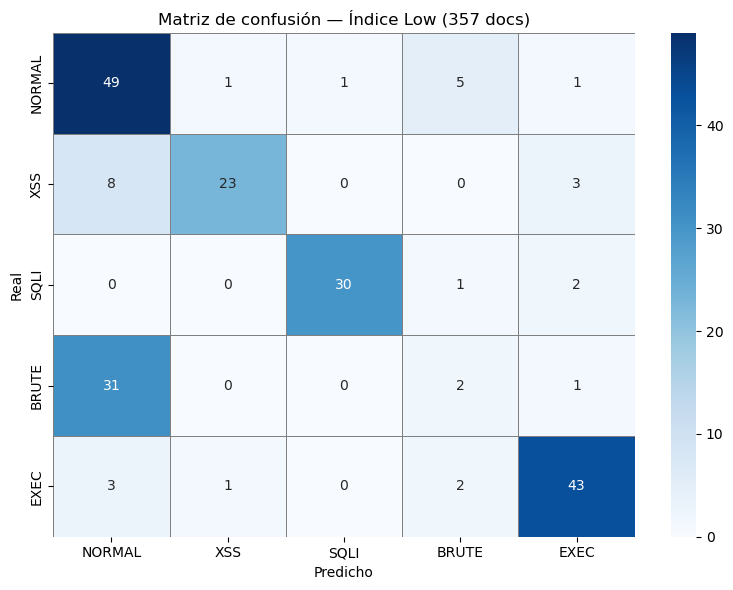

In [25]:

import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import os

plt.style.use('default')

matriz = np.array([
    [49, 1, 1, 5,  1],
    [ 8,23, 0, 0,  3],
    [ 0, 0,30, 1,  2],
    [31, 0, 0, 2,  1],
    [ 3, 1, 0, 2, 43]
])

etiquetas = ['NORMAL', 'XSS', 'SQLI', 'BRUTE', 'EXEC']

os.makedirs('img', exist_ok=True)

plt.figure(figsize=(8,6), facecolor='white')
sns.heatmap(matriz, annot=True, fmt='d', cmap='Blues',
            xticklabels=etiquetas, yticklabels=etiquetas,
            linewidths=0.5, linecolor='gray')
plt.xlabel('Predicho', color='black')
plt.ylabel('Real', color='black')
plt.title('Matriz de confusión — Índice Low (357 docs)', color='black')
plt.tick_params(colors='black')
plt.tight_layout()
plt.savefig('img/matriz_confusion_etapa1.png', dpi=300,
            bbox_inches='tight', facecolor='white')
plt.show()


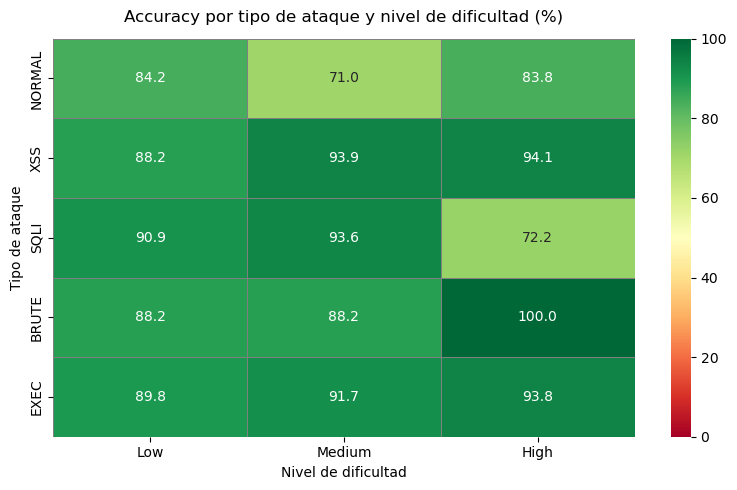

In [28]:

import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import os

plt.style.use('default')
os.makedirs('img', exist_ok=True)

datos = np.array([
    [84.2, 71.0, 83.8],
    [88.2, 93.9, 94.1],
    [90.9, 93.6, 72.2],
    [88.2, 88.2, 100.0],
    [89.8, 91.7, 93.8]
])

ataques = ['NORMAL', 'XSS', 'SQLI', 'BRUTE', 'EXEC']
niveles = ['Low', 'Medium', 'High']

plt.figure(figsize=(8, 5), facecolor='white')
sns.heatmap(datos, annot=True, fmt='.1f', cmap='RdYlGn',
            xticklabels=niveles, yticklabels=ataques,
            vmin=0, vmax=100, linewidths=0.5, linecolor='gray')
plt.title('Accuracy por tipo de ataque y nivel de dificultad (%)',
          color='black', pad=12)
plt.xlabel('Nivel de dificultad', color='black')
plt.ylabel('Tipo de ataque', color='black')
plt.tick_params(colors='black')
plt.tight_layout()
plt.savefig('img/heatmap_accuracy_c1.png', dpi=300,
            bbox_inches='tight', facecolor='white')
plt.show()

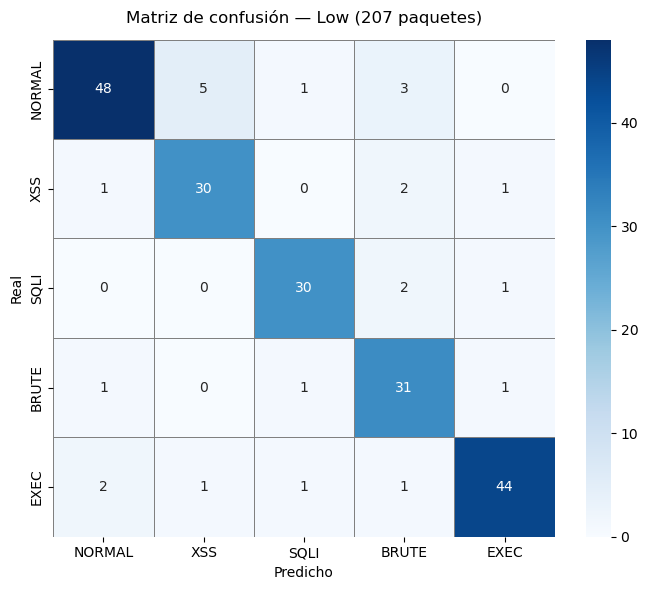

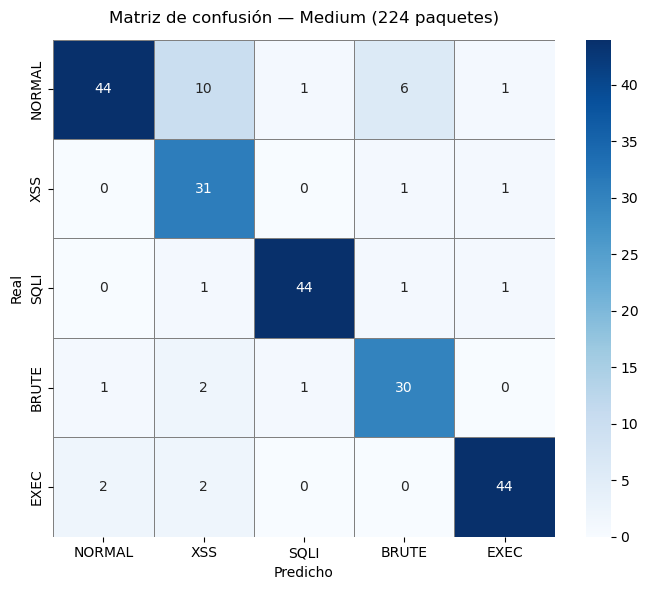

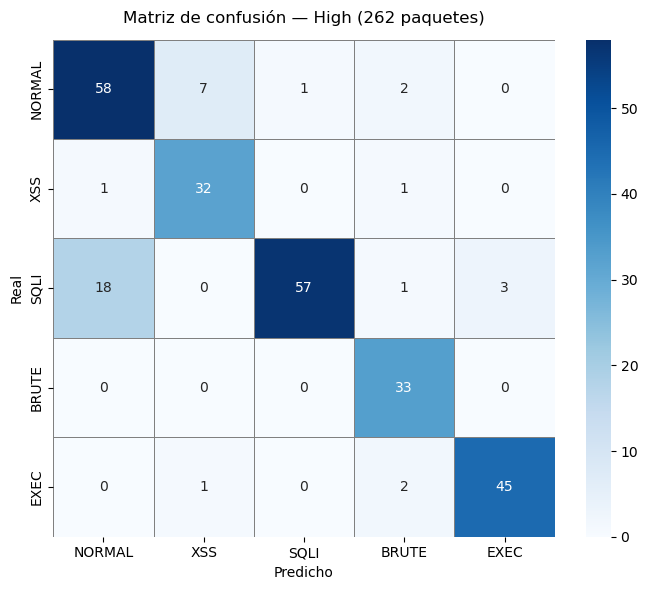

In [36]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import os

plt.style.use('default')
os.makedirs('img', exist_ok=True)

etiquetas = ['NORMAL', 'XSS', 'SQLI', 'BRUTE', 'EXEC']

matrices = {
    'matriz_confusion_low': (
        np.array([
            [48,  5,  1,  3,  0],
            [ 1, 30,  0,  2,  1],
            [ 0,  0, 30,  2,  1],
            [ 1,  0,  1, 31,  1],
            [ 2,  1,  1,  1, 44]
        ]),
        'Low (207 paquetes)'
    ),
    'matriz_confusion_medium': (
        np.array([
            [44, 10,  1,  6,  1],
            [ 0, 31,  0,  1,  1],
            [ 0,  1, 44,  1,  1],
            [ 1,  2,  1, 30,  0],
            [ 2,  2,  0,  0, 44]
        ]),
        'Medium (224 paquetes)'
    ),
    'matriz_confusion_high': (
        np.array([
            [58,  7,  1,  2,  0],
            [ 1, 32,  0,  1,  0],
            [18,  0, 57,  1,  3],
            [ 0,  0,  0, 33,  0],
            [ 0,  1,  0,  2, 45]
        ]),
        'High (262 paquetes)'
    )
}

for nombre, (matriz, titulo) in matrices.items():
    plt.figure(figsize=(7, 6), facecolor='white')
    sns.heatmap(matriz, annot=True, fmt='d', cmap='Blues',
                xticklabels=etiquetas, yticklabels=etiquetas,
                linewidths=0.5, linecolor='gray')
    plt.title(f'Matriz de confusión — {titulo}', color='black', pad=12)
    plt.xlabel('Predicho', color='black')
    plt.ylabel('Real', color='black')
    plt.tick_params(colors='black')
    plt.tight_layout()
    plt.savefig(f'img/{nombre}.png', dpi=300,
                bbox_inches='tight', facecolor='white')
    plt.show()
    plt.close()

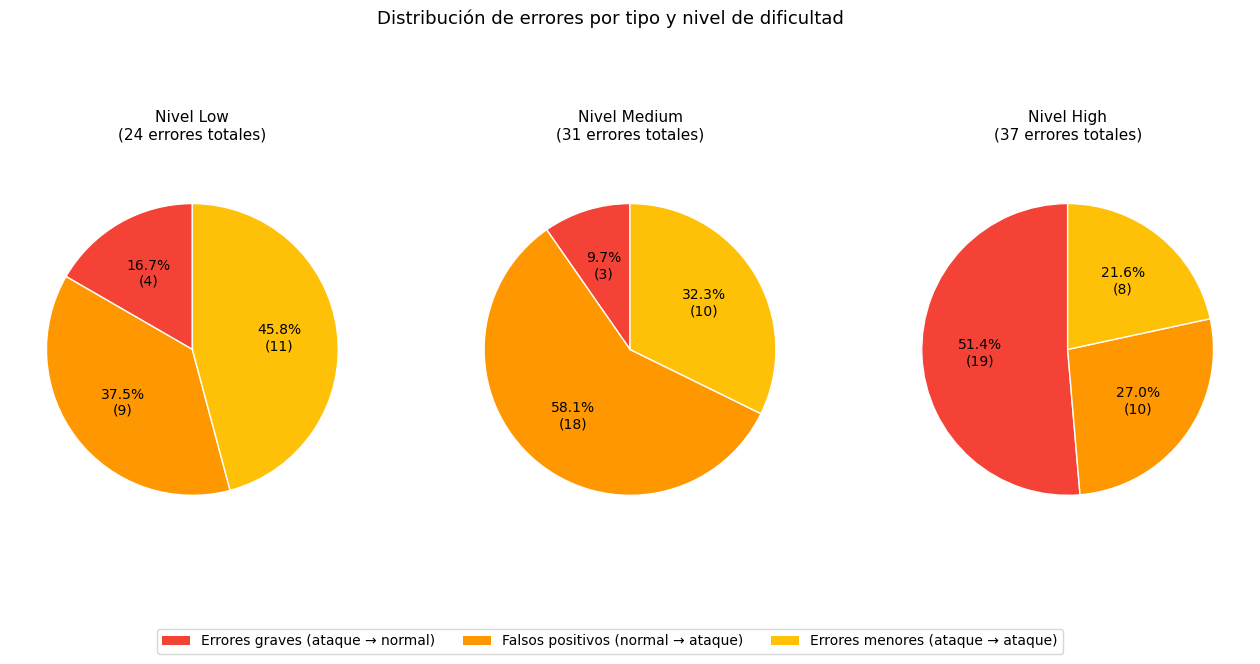

In [39]:
import matplotlib.pyplot as plt
import numpy as np
import os
from matplotlib.patches import Patch

plt.style.use('default')
os.makedirs('img', exist_ok=True)

datos = {
    'Low': {'valores': [4, 9, 11], 'total_errores': 24},
    'Medium': {'valores': [3, 18, 10], 'total_errores': 31},
    'High': {'valores': [19, 10, 8], 'total_errores': 37}
}

colores = ['#F44336', '#FF9800', '#FFC107']
etiquetas = [
    'Errores graves (ataque → normal)',
    'Falsos positivos (normal → ataque)',
    'Errores menores (ataque → ataque)'
]

fig, axes = plt.subplots(1, 3, figsize=(16, 7), facecolor='white')
fig.subplots_adjust(top=0.82)

for ax, (nivel, info) in zip(axes, datos.items()):
    valores = info['valores']
    total = info['total_errores']

    wedges, texts, autotexts = ax.pie(
        valores,
        colors=colores,
        autopct=lambda p: f'{p:.1f}%\n({int(round(p*total/100))})',
        startangle=90,
        wedgeprops={'linewidth': 1, 'edgecolor': 'white'}
    )

    for autotext in autotexts:
        autotext.set_fontsize(10)
        autotext.set_color('black')

    ax.set_title(f'Nivel {nivel}\n({total} errores totales)',
                 color='black', fontsize=11, pad=20)

leyenda = [Patch(facecolor=c, label=e) for c, e in zip(colores, etiquetas)]
fig.legend(handles=leyenda, loc='lower center', ncol=3,
           fontsize=10, frameon=True,
           bbox_to_anchor=(0.5, 0.02))

fig.suptitle('Distribución de errores por tipo y nivel de dificultad',
             color='black', fontsize=13, y=0.95)

plt.savefig('img/sectores_errores.png', dpi=300,
            bbox_inches='tight', facecolor='white')
plt.show()

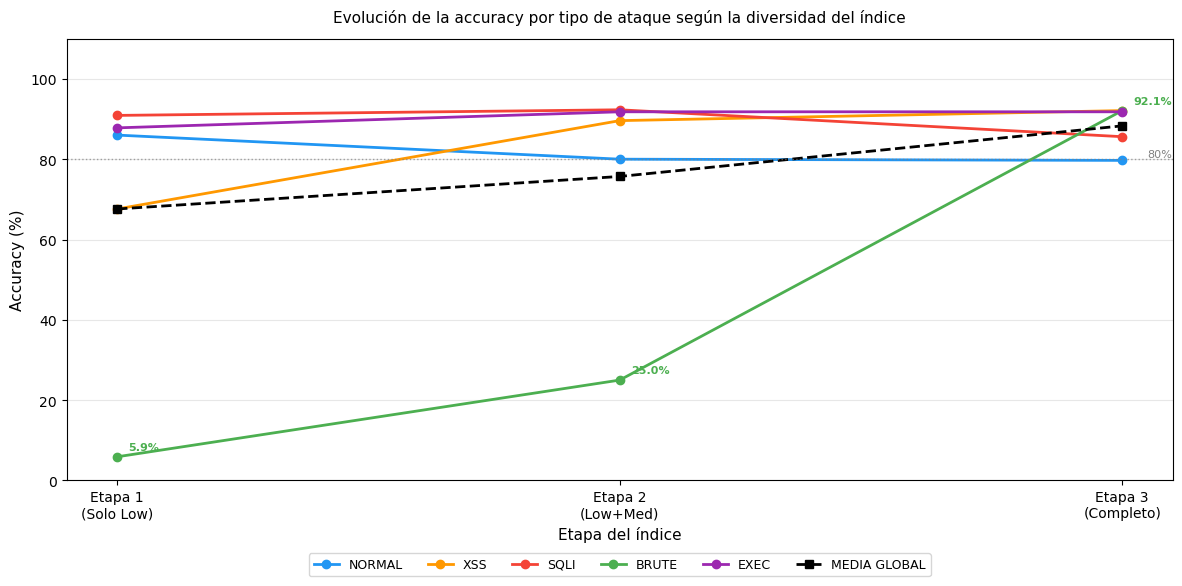

In [41]:
import matplotlib.pyplot as plt
import os

plt.style.use('default')
os.makedirs('img', exist_ok=True)

niveles = ['Etapa 1\n(Solo Low)', 'Etapa 2\n(Low+Med)', 'Etapa 3\n(Completo)']

normal = [86.0, 80.0, 79.7]
xss    = [67.6, 89.6, 92.1]
sqli   = [90.9, 92.3, 85.6]
brute  = [ 5.9, 25.0, 92.1]
exec_  = [87.8, 91.8, 91.8]
media  = [67.6, 75.7, 88.3]

fig, ax = plt.subplots(figsize=(12, 6), facecolor='white')

ax.plot(niveles, normal, marker='o', label='NORMAL',       color='#2196F3', linewidth=2)
ax.plot(niveles, xss,    marker='o', label='XSS',          color='#FF9800', linewidth=2)
ax.plot(niveles, sqli,   marker='o', label='SQLI',         color='#F44336', linewidth=2)
ax.plot(niveles, brute,  marker='o', label='BRUTE',        color='#4CAF50', linewidth=2)
ax.plot(niveles, exec_,  marker='o', label='EXEC',         color='#9C27B0', linewidth=2)
ax.plot(niveles, media,  marker='s', label='MEDIA GLOBAL', color='black',   linewidth=2, linestyle='--')

ax.annotate(f'{brute[0]}%', (niveles[0], brute[0]),
            textcoords="offset points", xytext=(8, 5),
            color='#4CAF50', fontsize=8, fontweight='bold')
ax.annotate(f'{brute[1]}%', (niveles[1], brute[1]),
            textcoords="offset points", xytext=(8, 5),
            color='#4CAF50', fontsize=8, fontweight='bold')
ax.annotate(f'{brute[2]}%', (niveles[2], brute[2]),
            textcoords="offset points", xytext=(8, 5),
            color='#4CAF50', fontsize=8, fontweight='bold')

ax.axhline(y=80, color='gray', linestyle=':', linewidth=1, alpha=0.7)
ax.text(2.05, 80.5, '80%', color='gray', fontsize=8)

ax.set_xlabel('Etapa del índice', color='black', fontsize=11)
ax.set_ylabel('Accuracy (%)', color='black', fontsize=11)
ax.set_title('Evolución de la accuracy por tipo de ataque según la diversidad del índice',
             color='black', fontsize=11, pad=12)
ax.set_ylim(0, 110)
ax.tick_params(colors='black')
ax.grid(axis='y', alpha=0.3)

ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.15),
          ncol=6, fontsize=9, frameon=True)

plt.tight_layout()
plt.savefig('img/lineas_evolucion_indice.png', dpi=300,
            bbox_inches='tight', facecolor='white')
plt.show()

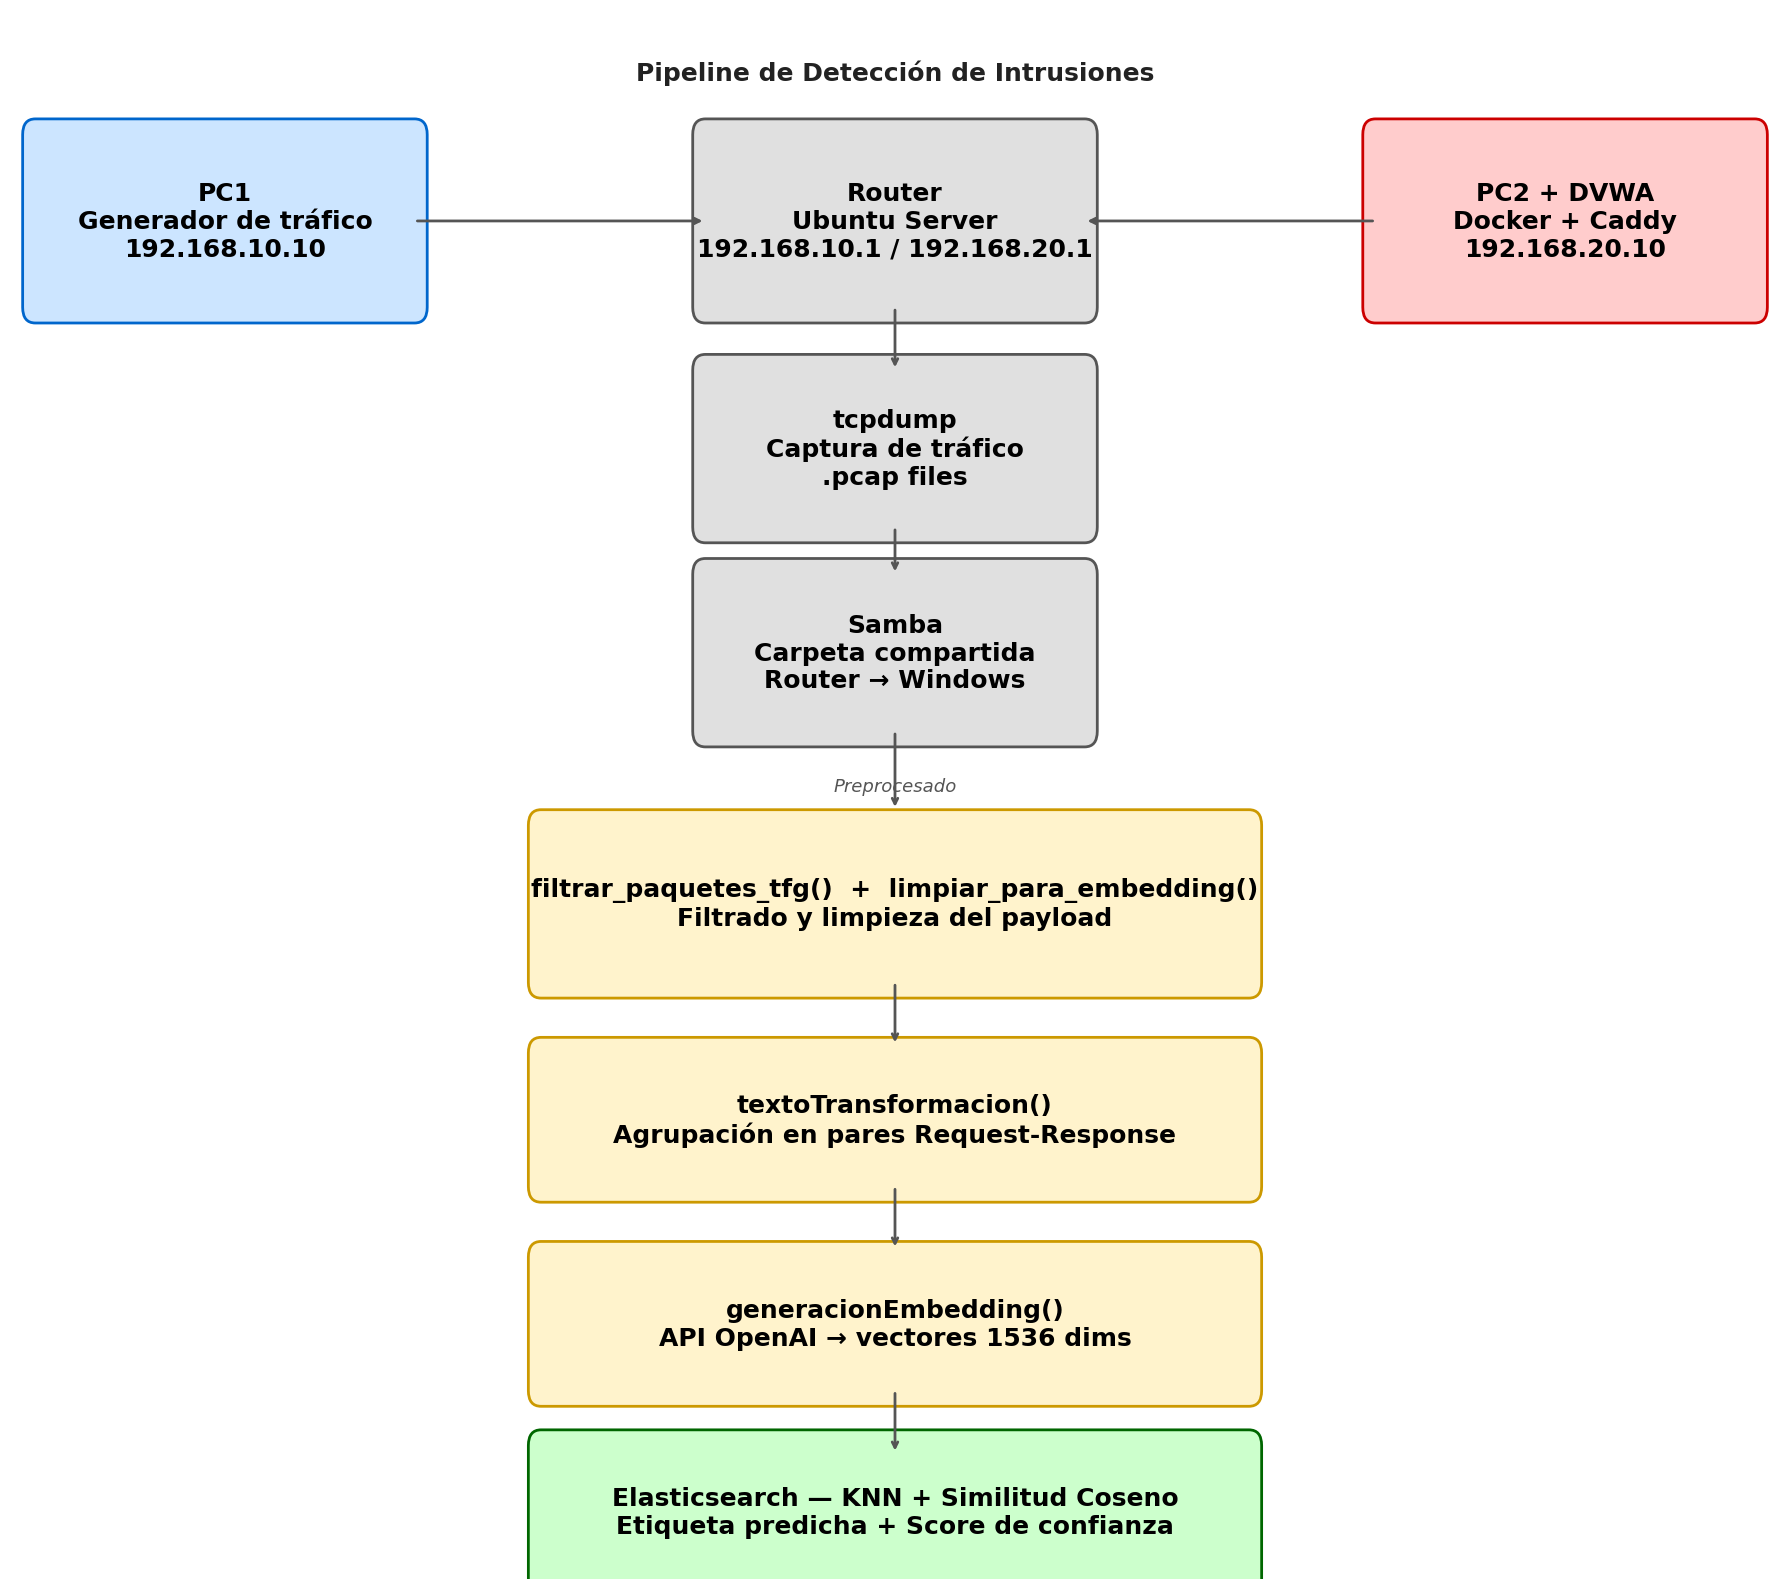

In [15]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import os

plt.style.use('default')
os.makedirs('img', exist_ok=True)

fig, ax = plt.subplots(1, 1, figsize=(18, 16), facecolor='white')
ax.set_xlim(0, 14)
ax.set_ylim(0, 10)
ax.axis('off')

def caja(ax, x, y, w, h, texto, color_fondo, color_borde, fontsize=20):
    rect = mpatches.FancyBboxPatch((x, y), w, h,
                                    boxstyle="round,pad=0.1",
                                    facecolor=color_fondo,
                                    edgecolor=color_borde,
                                    linewidth=2)
    ax.add_patch(rect)
    ax.text(x + w/2, y + h/2, texto, ha='center', va='center',
            fontsize=fontsize, color='black', fontweight='bold',
            multialignment='center')

def flecha(ax, x1, y1, x2, y2):
    ax.annotate('', xy=(x2, y2), xytext=(x1, y1),
                arrowprops=dict(arrowstyle='->', color='#555555', lw=2))
fontsize = 18
c_blue   = '#CCE5FF'
c_red    = '#FFCCCC'
c_gray   = '#E0E0E0'
c_yellow = '#FFF3CC'
c_green  = '#CCFFCC'

ax.text(7, 9.6, 'Pipeline de Detección de Intrusiones',
        ha='center', va='center', fontsize=18, fontweight='bold', color='#222222')

caja(ax, 0.2, 8.1, 3.0, 1.1, 'PC1\nGenerador de tráfico\n192.168.10.10', c_blue, '#0066CC', fontsize)
caja(ax, 5.5, 8.1, 3.0, 1.1, 'Router\nUbuntu Server\n192.168.10.1 / 192.168.20.1', c_gray, '#555555', fontsize)
caja(ax, 10.8, 8.1, 3.0, 1.1, 'PC2 + DVWA\nDocker + Caddy\n192.168.20.10', c_red, '#CC0000', fontsize)

flecha(ax, 3.2, 8.65, 5.5, 8.65)
flecha(ax, 10.8, 8.65, 8.5, 8.65)

caja(ax, 5.5, 6.7, 3.0, 1.0, 'tcpdump\nCaptura de tráfico\n.pcap files', c_gray, '#555555', fontsize)
flecha(ax, 7.0, 8.1, 7.0, 7.7)

caja(ax, 5.5, 5.4, 3.0, 1.0, 'Samba\nCarpeta compartida\nRouter → Windows', c_gray, '#555555', fontsize)
flecha(ax, 7.0, 6.7, 7.0, 6.4)

ax.text(7, 5.05, 'Preprocesado', ha='center', va='center',
        fontsize=13, color='#555555', style='italic')
flecha(ax, 7.0, 5.4, 7.0, 4.9)

caja(ax, 4.2, 3.8, 5.6, 1.0,
     'filtrar_paquetes_tfg()  +  limpiar_para_embedding()\nFiltrado y limpieza del payload',
     c_yellow, '#CC9900', fontsize)
flecha(ax, 7.0, 3.8, 7.0, 3.4)

caja(ax, 4.2, 2.5, 5.6, 0.85,
     'textoTransformacion()\nAgrupación en pares Request-Response',
     c_yellow, '#CC9900', fontsize)
flecha(ax, 7.0, 2.5, 7.0, 2.1)

caja(ax, 4.2, 1.2, 5.6, 0.85,
     'generacionEmbedding()\nAPI OpenAI → vectores 1536 dims',
     c_yellow, '#CC9900', fontsize)
flecha(ax, 7.0, 1.2, 7.0, 0.8)

caja(ax, 4.2, 0.0, 5.6, 0.85,
     'Elasticsearch — KNN + Similitud Coseno\nEtiqueta predicha + Score de confianza',
     c_green, '#006600', fontsize)

plt.tight_layout()
plt.savefig('img/pipeline_completo.png', dpi=300,
            bbox_inches='tight', facecolor='white')
plt.show()

In [41]:
import matplotlib.pyplot as plt
import numpy as np

ataques = ['NORMAL', 'XSS', 'SQLI', 'BRUTE', 'EXEC']

c1 = [79.7, 92.1, 85.6, 92.1, 91.8]
c2 = [83.0, 87.1, 58.4, 69.5, 90.4]
c3 = [79.6, 90.1, 81.3, 60.7, 89.7]

x = np.arange(len(ataques))
width = 0.25

fig, ax = plt.subplots(figsize=(12, 6))
fig.patch.set_facecolor('#F8F9FA')
ax.set_facecolor('#F8F9FA')

bars1 = ax.bar(x - width, c1, width, label='C1 — URL Real / URL Real',
               color='#2ECC71', edgecolor='white', linewidth=0.8)
bars2 = ax.bar(x, c2, width, label='C2 — URL Real / URL Aleatoria',
               color='#E74C3C', edgecolor='white', linewidth=0.8)
bars3 = ax.bar(x + width, c3, width, label='C3 — URL Aleatoria / URL Aleatoria',
               color='#4A90D9', edgecolor='white', linewidth=0.8)

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.8,
            f'{bar.get_height():.1f}%', ha='center', va='bottom',
            fontsize=7.5, color='#2C3E50', fontweight='bold')

for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.8,
            f'{bar.get_height():.1f}%', ha='center', va='bottom',
            fontsize=7.5, color='#2C3E50', fontweight='bold')

for bar in bars3:
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.8,
            f'{bar.get_height():.1f}%', ha='center', va='bottom',
            fontsize=7.5, color='#2C3E50', fontweight='bold')

ax.axhline(y=88.3, color='#2ECC71', linestyle='--', linewidth=1.2, alpha=0.6)
ax.axhline(y=77.7, color='#E74C3C', linestyle='--', linewidth=1.2, alpha=0.6)
ax.axhline(y=80.3, color='#4A90D9', linestyle='--', linewidth=1.2, alpha=0.6)

ax.set_xlabel('Tipo de ataque', fontsize=11, color='#2C3E50', labelpad=10)
ax.set_ylabel('Accuracy (%)', fontsize=11, color='#2C3E50', labelpad=10)
ax.set_title('Comparativa de accuracy por tipo de ataque y casuística\n(media de los tres niveles de dificultad)',
             fontsize=12, fontweight='bold', color='#2C3E50', pad=15)

ax.set_xticks(x)
ax.set_xticklabels(ataques, fontsize=10, color='#2C3E50')
ax.set_ylim(0, 110)
ax.set_yticks(range(0, 101, 10))
ax.tick_params(colors='#2C3E50')

ax.legend(loc='lower right', fontsize=9, framealpha=0.9, edgecolor='#BDC3C7')
ax.yaxis.grid(True, alpha=0.4, color='#BDC3C7')
ax.set_axisbelow(True)

for spine in ax.spines.values():
    spine.set_edgecolor('#BDC3C7')

plt.tight_layout()

carpeta = r'C:\Users\marti\Desktop\TrabajodeFindeGrado\pcapsrouter\img\Graficos'

plt.savefig(carpeta + r'\ablacion_comparativa.svg', format='svg', bbox_inches='tight')
plt.savefig(carpeta + r'\ablacion_comparativa.pdf', format='pdf', bbox_inches='tight')
plt.savefig(carpeta + r'\ablacion_comparativa.png', dpi=300, bbox_inches='tight')
plt.close()
print("Figuras guardadas en", carpeta)

Figuras guardadas en C:\Users\marti\Desktop\TrabajodeFindeGrado\pcapsrouter\img\Graficos


In [4]:
from docx import Document
from docx.shared import Pt, RGBColor
from docx.enum.text import WD_ALIGN_PARAGRAPH

# Datos separados por nivel
datos_low = [
    ("NORMAL", "0.994376", "46", "2",  "5",  "4",  "55.6%",  "95.8%",  "normal"),
    ("XSS",    "0.994970", "29", "1",  "1",  "3",  "25.0%",  "96.7%",  "normal"),
    ("SQLI",   "0.995344", "26", "4",  "2",  "1",  "66.7%",  "86.7%",  "inverso"),
    ("BRUTE",  "0.997664", "27", "3",  "2",  "2",  "50.0%",  "90.0%",  "normal"),
    ("EXEC",   "0.995504", "37", "7",  "3",  "2",  "60.0%",  "84.1%",  "normal"),
]

datos_medium = [
    ("NORMAL", "0.995532", "34", "11", "11", "6",  "64.7%",  "75.6%",  "normal"),
    ("XSS",    "0.998708", "28", "3",  "1",  "1",  "50.0%",  "90.3%",  "normal"),
    ("SQLI",   "0.998013", "42", "2",  "2",  "1",  "66.7%",  "95.5%",  "normal"),
    ("BRUTE",  "0.992222", "30", "0",  "2",  "2",  "50.0%",  "100.0%", "normal"),
    ("EXEC",   "0.998295", "18", "26", "3",  "1",  "75.0%",  "40.9%",  "inverso"),
]

datos_high = [
    ("NORMAL", "0.996425", "45", "12", "7",  "4",  "63.6%",  "78.9%",  "normal"),
    ("XSS",    "0.997164", "32", "0",  "2",  "0",  "100.0%", "100.0%", "normal"),
    ("SQLI",   "0.996356", "28", "29", "20", "2",  "90.9%",  "49.1%",  "inverso"),
    ("BRUTE",  "N/A",      "---","---","---","---", "---",    "---",    "sin errores"),
    ("EXEC",   "0.998927", "31", "14", "1",  "2",  "33.3%",  "68.9%",  "normal"),
]

cabeceras = ["Ataque", "Umbral", "VP", "FN", "VN", "FP", "%Detect_err", "%Conf_ok", "Patrón"]

niveles = [
    ("Low",    datos_low),
    ("Medium", datos_medium),
    ("High",   datos_high),
]

doc = Document()

for nivel, datos in niveles:

    # Título de la tabla
    p = doc.add_paragraph()
    p.alignment = WD_ALIGN_PARAGRAPH.CENTER
    run = p.add_run(f"Tabla X. Resultados del análisis de umbral de confianza — Nivel {nivel}.")
    run.font.size = Pt(10)
    run.font.italic = True

    # Crear tabla
    tabla = doc.add_table(rows=1, cols=len(cabeceras))
    tabla.style = 'Table Grid'

    # Cabecera
    fila_cab = tabla.rows[0].cells
    for i, cab in enumerate(cabeceras):
        fila_cab[i].text = cab
        fila_cab[i].paragraphs[0].runs[0].font.bold = True
        fila_cab[i].paragraphs[0].runs[0].font.size = Pt(9)
        fila_cab[i].paragraphs[0].alignment = WD_ALIGN_PARAGRAPH.CENTER

    # Filas de datos
    for fila in datos:
        row = tabla.add_row().cells
        for i, valor in enumerate(fila):
            row[i].text = valor
            run = row[i].paragraphs[0].runs[0]
            run.font.size = Pt(9)
            row[i].paragraphs[0].alignment = WD_ALIGN_PARAGRAPH.CENTER
            if fila[8] == "inverso":
                run.font.color.rgb = RGBColor(0xE7, 0x4C, 0x3C)
            elif fila[8] == "sin errores":
                run.font.color.rgb = RGBColor(0x2E, 0xCC, 0x71)

    # Espacio entre tablas
    doc.add_paragraph()

carpeta = r'C:\Users\marti\Desktop\TrabajodeFindeGrado\pcapsrouter\img\Graficos'
doc.save(carpeta + r'\tabla_scores.docx')
print("Tablas guardadas en", carpeta)

Tablas guardadas en C:\Users\marti\Desktop\TrabajodeFindeGrado\pcapsrouter\img\Graficos


In [2]:
pip install python-docx